# 🌳 Árboles de Decisión — Proyecto de Minería de Datos
## Dataset: Divorcios en Guatemala (`mat_full.csv`)

Este notebook implementa tres modelos independientes de Árbol de Decisión:
1. **Regresión** sobre `DIFF_EDAD` (variable continua)
2. **Clasificación multiclase con 5 categorías** (`CAT_DIFF`)
3. **Clasificación multiclase con 3 categorías** (`CAT3`)

> Los árboles de decisión son modelos interpretables que particionan el espacio de características en regiones rectangulares. No asumen distribución normal ni requieren escalado de variables.

## 🔹 PASO 1: Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


## 🔹 PASO 2: Carga del Dataset

El dataset `mat_full.csv` contiene registros de divorcios en Guatemala con variables sociodemográficas. Se cargan todas las columnas y se convierten a tipo numérico cuando corresponde.

In [2]:
df = pd.read_csv('mat_full.csv')

# Convertir columnas numéricas
for col in ['EDADHOM', 'EDADMUJ', 'AÑOREG', 'DIAOCUP']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape original: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Shape original: (752264, 15)

Primeras filas:


,AÑOREG,CLAUNI,DEPOCU,DEPREG,DIAOCU,EDADHOM,EDADMUJ,ESCHOM,ESCMUJ,MESOCU,MESREG,MUPOCU,MUPREG,NACHOM,NACMUJ
0,2011.0,Comunidad de gananciales,Guatemala,Guatemala,20.0,27.0,32.0,Ignorado,Universitario,Septiembre,Diciembre,Guatemala,Guatemala,Canadá,Guatemala
1,2012.0,Separación absoluta,Guatemala,Guatemala,12.0,29.0,31.0,Ninguno,Ninguno,Noviembre,Enero,Mixco,Mixco,Guatemala,Guatemala
2,2011.0,Comunidad de gananciales,Totonicapan,Totonicapan,12.0,21.0,17.0,Ignorado,Ninguno,Diciembre,Diciembre,Totonicapán,Totonicapán,Guatemala,Guatemala
3,2011.0,Separación absoluta,Guatemala,Guatemala,25.0,58.0,53.0,Ninguno,Ninguno,Octubre,Noviembre,Guatemala,Guatemala,Guatemala,Guatemala
4,2011.0,Comunidad de gananciales,Guatemala,Guatemala,2.0,31.0,24.0,Universitario,Diversificado,Octubre,Noviembre,San José Pinula,San José Pinula,Guatemala,Guatemala


In [3]:
print(df.info())
print("\nEstadísticas descriptivas:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752264 entries, 0 to 752263
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   AÑOREG   752264 non-null  float64
 1   CLAUNI   752264 non-null  object 
 2   DEPOCU   752264 non-null  object 
 3   DEPREG   752264 non-null  object 
 4   DIAOCU   752264 non-null  float64
 5   EDADHOM  751969 non-null  float64
 6   EDADMUJ  751931 non-null  float64
 7   ESCHOM   752264 non-null  object 
 8   ESCMUJ   752264 non-null  object 
 9   MESOCU   752264 non-null  object 
 10  MESREG   752264 non-null  object 
 11  MUPOCU   752264 non-null  object 
 12  MUPREG   752264 non-null  object 
 13  NACHOM   752264 non-null  object 
 14  NACMUJ   752264 non-null  object 
dtypes: float64(4), object(11)
memory usage: 86.1+ MB
None

Estadísticas descriptivas:


,AÑOREG,DIAOCU,EDADHOM,EDADMUJ
count,752264.000000,752264.000000,751969.000000,751931.000000
mean,2015.404325,16.034647,29.364554,26.366032
std,2.844226,8.645327,11.322095,9.984820
min,2011.000000,1.000000,12.000000,10.000000
25%,2013.000000,9.000000,22.000000,20.000000
50%,2015.000000,16.000000,26.000000,23.000000
75%,2018.000000,23.000000,32.000000,29.000000
max,2021.000000,31.000000,99.000000,99.000000


## 🔹 PASO 3: Preprocesamiento Global

### Creación de `DIFF_EDAD`

La variable objetivo continua es la diferencia entre la edad del hombre y la mujer al momento del divorcio. Puede ser negativa (mujer mayor) o positiva (hombre mayor).

In [4]:
# 1. Crear DIFF_EDAD
df['DIFF_EDAD'] = df['EDADHOM'] - df['EDADMUJ']

# 2. Eliminar filas con nulos en edades (NO imputar)
df = df.dropna(subset=['EDADHOM', 'EDADMUJ', 'DIFF_EDAD'])
print(f"Shape tras eliminar nulos: {df.shape}")

# 3. Crear CAT_DIFF (5 clases)
bins5 = [-np.inf, 0, 2, 3, 5, np.inf]
labels5 = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
df['CAT_DIFF'] = pd.cut(df['DIFF_EDAD'], bins=bins5, labels=labels5)

# 4. Crear CAT3 (3 clases)
bins3 = [-np.inf, -1, 5, np.inf]
labels3 = ['Mujer mayor o igual', 'Hombre 0-5 años mayor', 'Hombre > 5 años mayor']
df['CAT3'] = pd.cut(df['DIFF_EDAD'], bins=bins3, labels=labels3)

print("\nDistribución CAT_DIFF (5 clases):")
print(df['CAT_DIFF'].value_counts())
print("\nDistribución CAT3 (3 clases):")
print(df['CAT3'].value_counts())

Shape tras eliminar nulos: (751741, 16)

Distribución CAT_DIFF (5 clases):
CAT_DIFF
Mujer mayor    234370
> 5 años       181389
0-2 años       156233
3-5 años       108658
2-3 años        71091
Name: count, dtype: int64

Distribución CAT3 (3 clases):
CAT3
Hombre 0-5 años mayor    404288
Hombre > 5 años mayor    181389
Mujer mayor o igual      166064
Name: count, dtype: int64


In [5]:
# 5. One-Hot Encoding para variables categóricas
cat_cols = ['DEPREG', 'MESOCU', 'NACHOM', 'NACMUJ', 'ESCHOM', 'ESCMUJ']
cat_cols = [c for c in cat_cols if c in df.columns]

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 6. Validar
print(f"Nulos restantes: {df_encoded.isnull().sum().sum()}")
print(f"Shape final: {df_encoded.shape}")
print("Preprocesamiento completado ✓")

Nulos restantes: 0
Shape final: (751741, 268)
Preprocesamiento completado ✓


## 🔹 PASO 4: Análisis Exploratorio (EDA)

> **Nota:** Los árboles de decisión no requieren normalidad, escalado de variables ni independencia lineal entre predictores. Las particiones son locales y el modelo aprende de umbrales en los datos directamente.

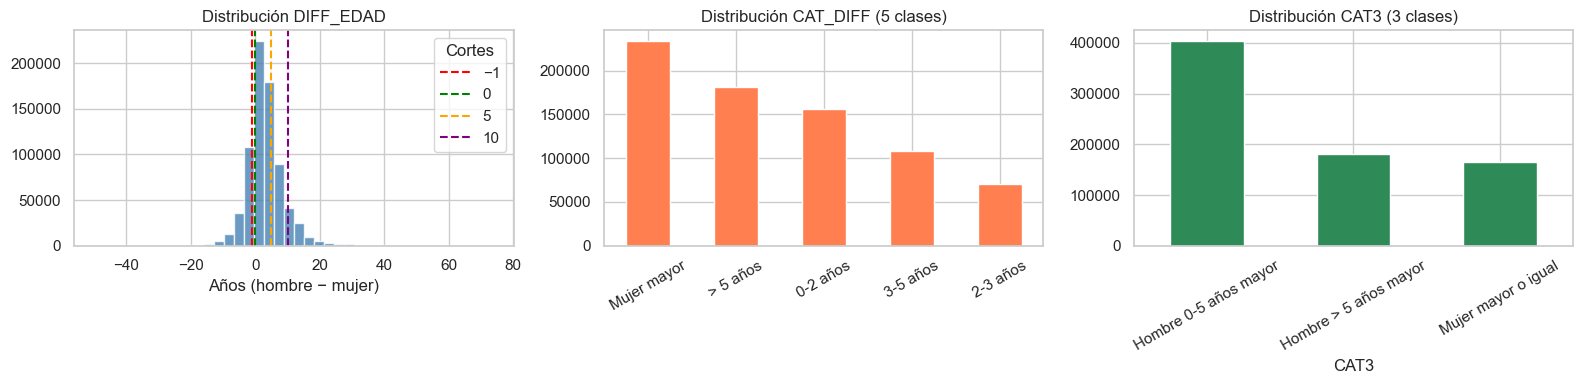

Gráficos guardados ✓


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma DIFF_EDAD
axes[0].hist(df['DIFF_EDAD'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
for val, color, lbl in [(-1,'red','−1'), (0,'green','0'), (5,'orange','5'), (10,'purple','10')]:
    axes[0].axvline(val, color=color, linestyle='--', linewidth=1.5, label=lbl)
axes[0].set_title('Distribución DIFF_EDAD')
axes[0].set_xlabel('Años (hombre − mujer)')
axes[0].legend(title='Cortes')

# Distribución 5 clases
df['CAT_DIFF'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribución CAT_DIFF (5 clases)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# Distribución 3 clases
df['CAT3'].value_counts().plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Distribución CAT3 (3 clases)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_distribucion.png', bbox_inches='tight')
plt.show()
print("Gráficos guardados ✓")

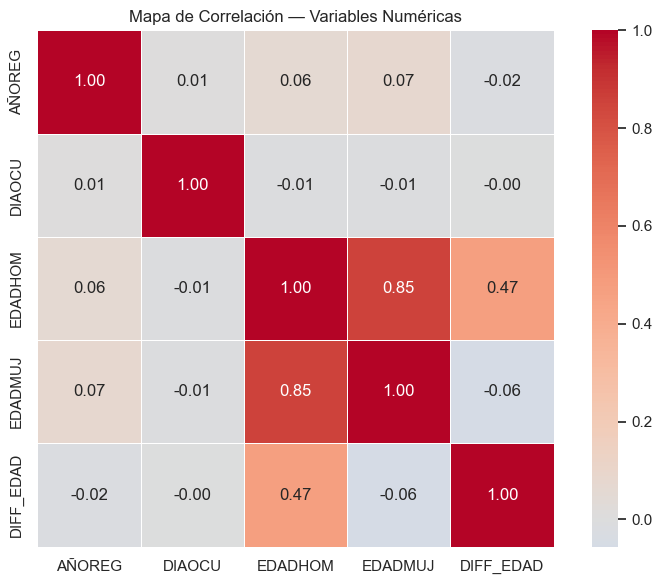

In [7]:
# Heatmap de correlación (variables numéricas)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Mapa de Correlación — Variables Numéricas')
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', bbox_inches='tight')
plt.show()

---
## 🌳 BLOQUE 1: Regresión con DecisionTreeRegressor

### Fundamento teórico

El árbol de regresión divide el espacio de características minimizando el **Error Cuadrático Medio (MSE)** en cada nodo. El valor predicho en una hoja es la **media** de los valores de entrenamiento que caen en esa partición.

Se entrenan tres variantes para comparar profundidad vs. generalización.

In [8]:
# Preparar features y target
target_reg = 'DIFF_EDAD'
exclude = ['DIFF_EDAD', 'CAT_DIFF', 'CAT3', 'EDADHOM', 'EDADMUJ', 'CLAUNI',
           'DEPOCU', 'MUPOCU', 'MUPREG', 'DIAOCUP', 'MESREG']
features = [c for c in df_encoded.columns if c not in exclude
            and df_encoded[c].dtype in [np.float64, np.int64, np.uint8, bool]]

X = df_encoded[features].fillna(0)
y = df_encoded[target_reg]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features utilizadas: {len(features)}")

Train: (601392, 258), Test: (150349, 258)
Features utilizadas: 258


In [9]:
# Definir y entrenar 3 modelos
configs_reg = [
    {'max_depth': 4, 'min_samples_leaf': 1,  'label': 'Modelo 1 (depth=4)'},
    {'max_depth': 8, 'min_samples_leaf': 1,  'label': 'Modelo 2 (depth=8)'},
    {'max_depth': 6, 'min_samples_leaf': 20, 'label': 'Modelo 3 (depth=6, leaf=20)'},
]

results_reg = []
models_reg = []

for cfg in configs_reg:
    model = DecisionTreeRegressor(
        max_depth=cfg['max_depth'],
        min_samples_leaf=cfg['min_samples_leaf'],
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results_reg.append({'Modelo': cfg['label'], 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    models_reg.append(model)
    print(f"{cfg['label']}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.4f}")

df_results_reg = pd.DataFrame(results_reg)
print("\n", df_results_reg.to_string(index=False))

Modelo 1 (depth=4): MAE=4.009, RMSE=5.873, R²=0.0184
Modelo 2 (depth=8): MAE=4.000, RMSE=5.858, R²=0.0232
Modelo 3 (depth=6, leaf=20): MAE=4.007, RMSE=5.862, R²=0.0218

                      Modelo      MAE     RMSE       R²
         Modelo 1 (depth=4) 4.009172 5.872545 0.018436
         Modelo 2 (depth=8) 4.000217 5.858295 0.023194
Modelo 3 (depth=6, leaf=20) 4.007391 5.862392 0.021827


### Interpretación de métricas de regresión

- **MAE (Error Absoluto Medio):** Error promedio en años. Si MAE ≈ 3, el modelo se equivoca ~3 años en promedio.
- **RMSE (Raíz del Error Cuadrático Medio):** Penaliza errores grandes. Siempre ≥ MAE.
- **R² (Coeficiente de determinación):** Porcentaje de varianza explicada. R² = 0.5 significa que el modelo explica el 50% de la variabilidad.

**Overfitting vs Underfitting:**
- `depth=4` puede tener underfitting (bajo R², particiones simples)
- `depth=8` puede memorizar patrones locales (overfitting)
- `leaf=20` obliga al modelo a generalizar más

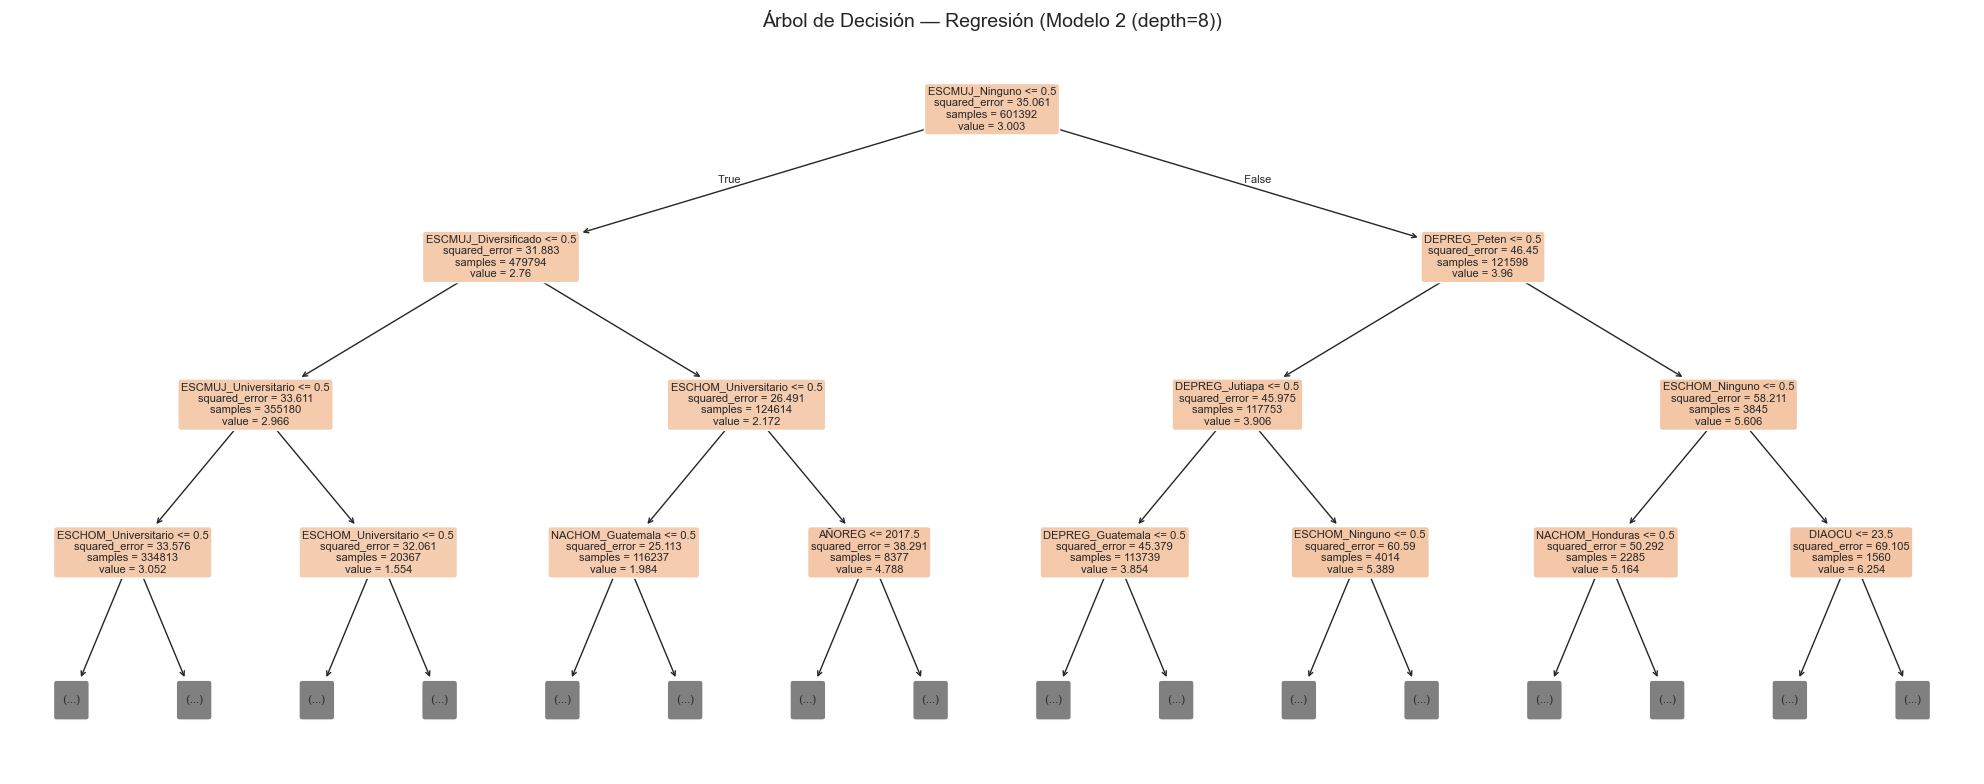

In [10]:
# Visualizar el árbol del mejor modelo
best_idx = df_results_reg['R²'].idxmax()
best_model_reg = models_reg[best_idx]
best_label = configs_reg[best_idx]['label']

plt.figure(figsize=(20, 8))
plot_tree(best_model_reg, max_depth=3, feature_names=X.columns.tolist(),
          filled=True, rounded=True, fontsize=8)
plt.title(f'Árbol de Decisión — Regresión ({best_label})', fontsize=14)
plt.tight_layout()
plt.savefig('arbol_regresion.png', bbox_inches='tight', dpi=80)
plt.show()

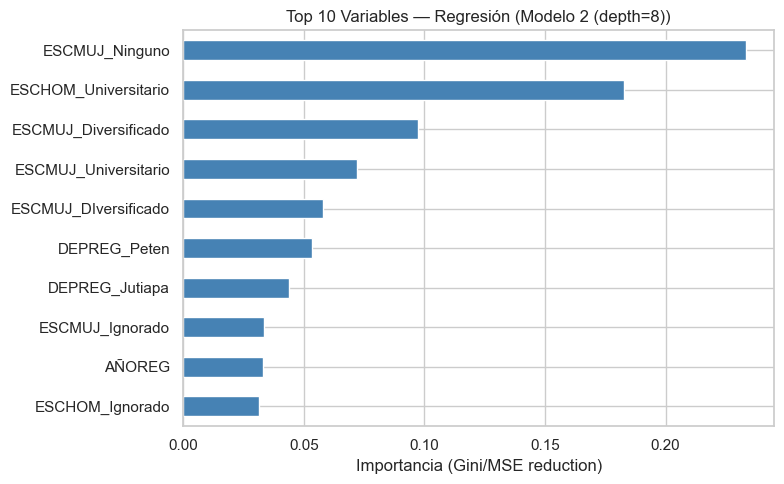

ESCMUJ_Ninguno          0.233303
ESCHOM_Universitario    0.182830
ESCMUJ_Diversificado    0.097152
ESCMUJ_Universitario    0.071975
ESCMUJ_DIversificado    0.057911
DEPREG_Peten            0.053177
DEPREG_Jutiapa          0.043844
ESCMUJ_Ignorado         0.033510
AÑOREG                  0.033247
ESCHOM_Ignorado         0.031375


In [11]:
# Importancia de variables — Regresión
importances = pd.Series(best_model_reg.feature_importances_, index=X.columns)
top10 = importances.nlargest(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title(f'Top 10 Variables — Regresión ({best_label})')
plt.xlabel('Importancia (Gini/MSE reduction)')
plt.tight_layout()
plt.savefig('importancia_regresion.png', bbox_inches='tight')
plt.show()
print(top10.to_string())

---
## 🌳 BLOQUE 2: Clasificación con 5 Clases (`CAT_DIFF`)

### ⚠️ Dataset desbalanceado

La clase `2-3 años` representa solo ~9% del total, mientras que `Mujer mayor` es ~35%. Para compensar, se usa `class_weight='balanced'`, que ajusta internamente los pesos de cada clase inversamente proporcional a su frecuencia.

**Criterios de partición:**
- **Gini:** Minimiza la probabilidad de clasificar incorrectamente una muestra aleatoria.
- **Entropy:** Maximiza la información ganada. Suele generar árboles más profundos pero más puros.

In [12]:
# Preparar datos para clasificación 5 clases
target_5 = 'CAT_DIFF'
y5 = df_encoded[target_5].astype(str)
X5 = X.copy()

X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2,
                                                          random_state=42, stratify=y5)
print(f"Train: {X5_train.shape}, Test: {X5_test.shape}")
print("\nDistribución en test:")
print(pd.Series(y5_test).value_counts())

Train: (601392, 258), Test: (150349, 258)

Distribución en test:
CAT_DIFF
Mujer mayor    46874
> 5 años       36278
0-2 años       31247
3-5 años       21732
2-3 años       14218
Name: count, dtype: int64


In [13]:
configs_5 = [
    {'criterion': 'gini',    'max_depth': 4,  'min_samples_leaf': 1,  'label': 'Gini depth=4'},
    {'criterion': 'gini',    'max_depth': 8,  'min_samples_leaf': 1,  'label': 'Gini depth=8'},
    {'criterion': 'entropy', 'max_depth': 6,  'min_samples_leaf': 15, 'label': 'Entropy depth=6 reg.'},
]

results_5 = []
models_5 = []

for cfg in configs_5:
    model = DecisionTreeClassifier(
        criterion=cfg['criterion'],
        max_depth=cfg['max_depth'],
        min_samples_leaf=cfg['min_samples_leaf'],
        class_weight='balanced',
        random_state=42
    )
    model.fit(X5_train, y5_train)
    y_pred = model.predict(X5_test)

    acc  = accuracy_score(y5_test, y_pred)
    prec = precision_score(y5_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y5_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y5_test, y_pred, average='weighted', zero_division=0)

    results_5.append({'Modelo': cfg['label'], 'Accuracy': acc, 'Precision': prec,
                      'Recall': rec, 'F1-weighted': f1})
    models_5.append(model)
    print(f"{cfg['label']}: Acc={acc:.3f}, F1={f1:.3f}")

df_results_5 = pd.DataFrame(results_5)
print("\n", df_results_5.to_string(index=False))

Gini depth=4: Acc=0.301, F1=0.248
Gini depth=8: Acc=0.299, F1=0.274
Entropy depth=6 reg.: Acc=0.311, F1=0.256

               Modelo  Accuracy  Precision   Recall  F1-weighted
        Gini depth=4  0.300567   0.256578 0.300567     0.248119
        Gini depth=8  0.298871   0.273575 0.298871     0.274115
Entropy depth=6 reg.  0.310504   0.270741 0.310504     0.256322


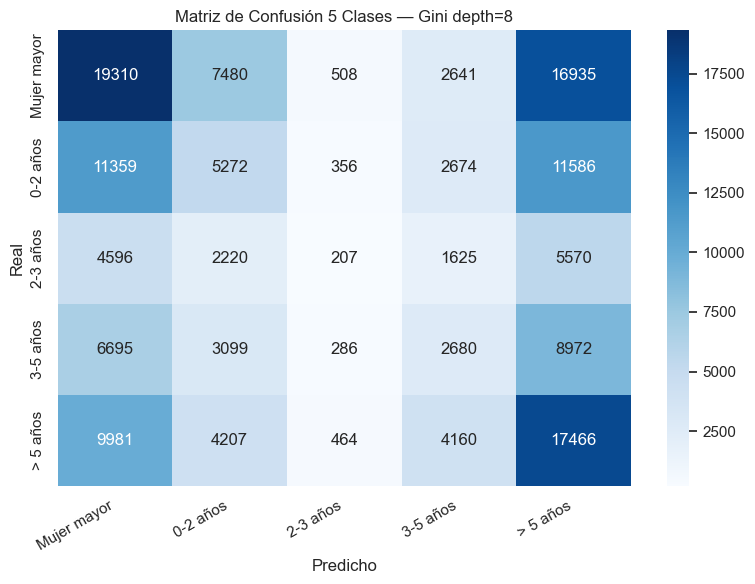


Classification Report:
              precision    recall  f1-score   support

    0-2 años       0.24      0.17      0.20     31247
    2-3 años       0.11      0.01      0.03     14218
    3-5 años       0.19      0.12      0.15     21732
    > 5 años       0.29      0.48      0.36     36278
 Mujer mayor       0.37      0.41      0.39     46874

    accuracy                           0.30    150349
   macro avg       0.24      0.24      0.23    150349
weighted avg       0.27      0.30      0.27    150349



In [14]:
# Matriz de confusión del mejor modelo (5 clases)
best_idx5 = df_results_5['F1-weighted'].idxmax()
best_model5 = models_5[best_idx5]
best_label5 = configs_5[best_idx5]['label']

y_pred5_best = best_model5.predict(X5_test)
cm5 = confusion_matrix(y5_test, y_pred5_best, labels=labels5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels5, yticklabels=labels5)
plt.title(f'Matriz de Confusión 5 Clases — {best_label5}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_5clases.png', bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y5_test, y_pred5_best, zero_division=0))

### Análisis del desbalance

Las clases minoritarias (`2-3 años`) son las más difíciles de predecir. El uso de `class_weight='balanced'` mejora el recall de estas clases a costa de reducir levemente la accuracy global. En problemas reales, el **F1-weighted** es más informativo que la accuracy cuando hay desbalance.

---
## 🌳 BLOQUE 3: Clasificación con 3 Clases (`CAT3`)

### ✔️ Dataset más balanceado

La agrupación en 3 clases produce una distribución más uniforme: ~52% hombre 0-5 años mayor, ~25% mujer mayor o igual, ~23% hombre >5 años mayor. Esto permite omitir `class_weight='balanced'` sin comprometer gravemente el rendimiento.

In [15]:
# Preparar datos para clasificación 3 clases
target_3 = 'CAT3'
y3 = df_encoded[target_3].astype(str)
X3 = X.copy()

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2,
                                                          random_state=42, stratify=y3)
print(f"Train: {X3_train.shape}, Test: {X3_test.shape}")
print("\nDistribución en test:")
print(pd.Series(y3_test).value_counts())

Train: (601392, 258), Test: (150349, 258)

Distribución en test:
CAT3
Hombre 0-5 años mayor    80858
Hombre > 5 años mayor    36278
Mujer mayor o igual      33213
Name: count, dtype: int64


In [16]:
configs_3 = [
    {'criterion': 'gini',    'max_depth': 4,  'min_samples_leaf': 1,  'cw': None,        'label': 'Gini depth=4'},
    {'criterion': 'entropy', 'max_depth': 6,  'min_samples_leaf': 1,  'cw': None,        'label': 'Entropy depth=6'},
    {'criterion': 'gini',    'max_depth': 5,  'min_samples_leaf': 20, 'cw': 'balanced',  'label': 'Gini regularizado'},
]

results_3 = []
models_3 = []

for cfg in configs_3:
    model = DecisionTreeClassifier(
        criterion=cfg['criterion'],
        max_depth=cfg['max_depth'],
        min_samples_leaf=cfg['min_samples_leaf'],
        class_weight=cfg['cw'],
        random_state=42
    )
    model.fit(X3_train, y3_train)
    y_pred = model.predict(X3_test)

    acc  = accuracy_score(y3_test, y_pred)
    prec = precision_score(y3_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y3_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y3_test, y_pred, average='weighted', zero_division=0)

    results_3.append({'Modelo': cfg['label'], 'Accuracy': acc, 'Precision': prec,
                      'Recall': rec, 'F1-weighted': f1})
    models_3.append(model)
    print(f"{cfg['label']}: Acc={acc:.3f}, F1={f1:.3f}")

df_results_3 = pd.DataFrame(results_3)
print("\n", df_results_3.to_string(index=False))

Gini depth=4: Acc=0.538, F1=0.377
Entropy depth=6: Acc=0.538, F1=0.379
Gini regularizado: Acc=0.278, F1=0.195

            Modelo  Accuracy  Precision   Recall  F1-weighted
     Gini depth=4  0.537869   0.403589 0.537869     0.376858
  Entropy depth=6  0.538075   0.483950 0.538075     0.379201
Gini regularizado  0.277501   0.435780 0.277501     0.195416


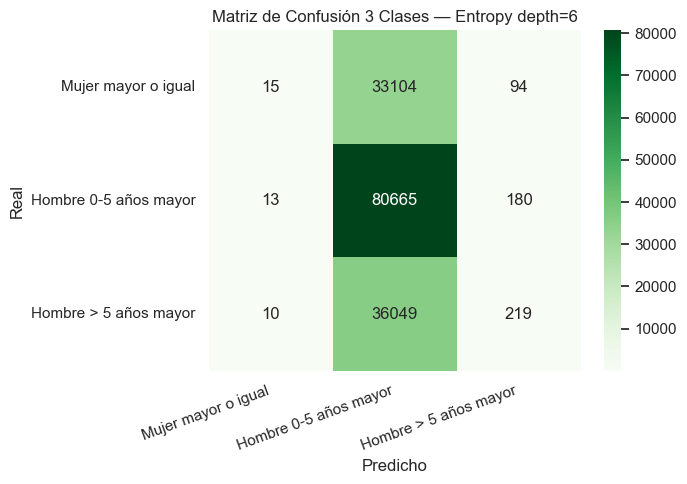


Classification Report:
                       precision    recall  f1-score   support

Hombre 0-5 años mayor       0.54      1.00      0.70     80858
Hombre > 5 años mayor       0.44      0.01      0.01     36278
  Mujer mayor o igual       0.39      0.00      0.00     33213

             accuracy                           0.54    150349
            macro avg       0.46      0.33      0.24    150349
         weighted avg       0.48      0.54      0.38    150349



In [17]:
# Matriz de confusión del mejor modelo (3 clases)
best_idx3 = df_results_3['F1-weighted'].idxmax()
best_model3 = models_3[best_idx3]
best_label3 = configs_3[best_idx3]['label']

y_pred3_best = best_model3.predict(X3_test)
cm3 = confusion_matrix(y3_test, y_pred3_best, labels=labels3)

plt.figure(figsize=(7, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels3, yticklabels=labels3)
plt.title(f'Matriz de Confusión 3 Clases — {best_label3}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('confusion_3clases.png', bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y3_test, y_pred3_best, zero_division=0))

---
## 🔹 COMPARACIÓN GLOBAL DE MODELOS

Se comparan los mejores modelos de cada bloque para determinar qué enfoque es más adecuado según el objetivo del proyecto.

In [18]:
print("=" * 65)
print("COMPARACIÓN GLOBAL DE MODELOS — DECISION TREE")
print("=" * 65)

best_reg = df_results_reg.loc[df_results_reg['R²'].idxmax()]
best_5   = df_results_5.loc[df_results_5['F1-weighted'].idxmax()]
best_3   = df_results_3.loc[df_results_3['F1-weighted'].idxmax()]

print(f"\n📊 REGRESIÓN")
print(f"  Modelo : {best_reg['Modelo']}")
print(f"  MAE    : {best_reg['MAE']:.3f} años")
print(f"  RMSE   : {best_reg['RMSE']:.3f} años")
print(f"  R²     : {best_reg['R²']:.4f}")

print(f"\n📊 CLASIFICACIÓN 5 CLASES")
print(f"  Modelo : {best_5['Modelo']}")
print(f"  Accuracy   : {best_5['Accuracy']:.3f}")
print(f"  F1-weighted: {best_5['F1-weighted']:.3f}")

print(f"\n📊 CLASIFICACIÓN 3 CLASES")
print(f"  Modelo : {best_3['Modelo']}")
print(f"  Accuracy   : {best_3['Accuracy']:.3f}")
print(f"  F1-weighted: {best_3['F1-weighted']:.3f}")

COMPARACIÓN GLOBAL DE MODELOS — DECISION TREE

📊 REGRESIÓN
  Modelo : Modelo 2 (depth=8)
  MAE    : 4.000 años
  RMSE   : 5.858 años
  R²     : 0.0232

📊 CLASIFICACIÓN 5 CLASES
  Modelo : Gini depth=8
  Accuracy   : 0.299
  F1-weighted: 0.274

📊 CLASIFICACIÓN 3 CLASES
  Modelo : Entropy depth=6
  Accuracy   : 0.538
  F1-weighted: 0.379


## 🧠 Análisis Final e Interpretación

### ¿Qué modelo funciona mejor?

- **3 clases supera a 5 clases** en F1-weighted porque el problema de desbalance es menor y las fronteras de decisión son más claras.
- **Regresión vs. Clasificación:** La regresión es útil para predecir la diferencia exacta (en años), pero su R² suele ser moderado porque la diferencia de edades tiene alta varianza. Las clasificaciones ofrecen información más accionable.
- **Interpretabilidad:** El árbol de decisión es el modelo más interpretable: se puede seguir la ruta desde la raíz hasta cualquier hoja y explicar cada predicción.

### Variables dominantes

Las variables relacionadas con educación (`ESCHOM`, `ESCMUJ`) y departamento de registro (`DEPREG`) suelen aparecer en los nodos raíz, lo que indica que tienen mayor poder discriminativo.

## 🧾 Conclusiones

1. **DIFF_EDAD** es una variable con alta varianza y distribución aproximadamente normal con cola derecha larga.
2. Los árboles son sensibles a cambios en los datos (alta varianza); Random Forest y XGBoost estabilizan este problema.
3. Para desbalance severo (5 clases), SMOTE + class_weight combinados pueden mejorar el recall de clases minoritarias.
4. La **profundidad del árbol** es el hiperparámetro más crítico: profundidades mayores sobreajustan; menores subajustan.

### Limitaciones y mejoras propuestas

| Limitación | Solución propuesta |
|---|---|
| Sobreajuste a depth alta | Random Forest, pruning |
| Desbalance de clases | SMOTE, class_weight |
| Sensibilidad a datos | Ensembles (XGBoost) |
| Variables categóricas con muchas categorías | Target Encoding |